<a href="https://colab.research.google.com/github/Daheeyah/Daheeyah/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IMPORTING LIBRARIES

In [2]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,precision_score,recall_score
)

### FOR CLEAN VISUALS

In [5]:
sns.set(style="whitegrid")

### UPLOADING THE DATASET (FROM KAGGLE)

In [17]:
df=pd.read_csv("/diabetes.csv")

In [18]:
print("first 5 rows of the dataset")
print(df.head())

first 5 rows of the dataset
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [19]:
print ("\Dataset info:")
print (df.info())

\Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2279/2640770347.py:1: SyntaxWarning: invalid escape sequence '\D'
  print ("\Dataset info:")


In [20]:
print ("\nMissingValues:")
print (df.isnull().sum())


MissingValues:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### DATA CLEANING

In [21]:
# Replace unrealistic 0s with NaN
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

print("\nAfter Cleaning:")
print(df.describe())


After Cleaning:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232    0.476951  
min     18.200000 

/tmp/ipykernel_2279/3503062891.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


###  EXPLORATORY DATA ANALYSIS (EDA)

/tmp/ipykernel_2279/2075069792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


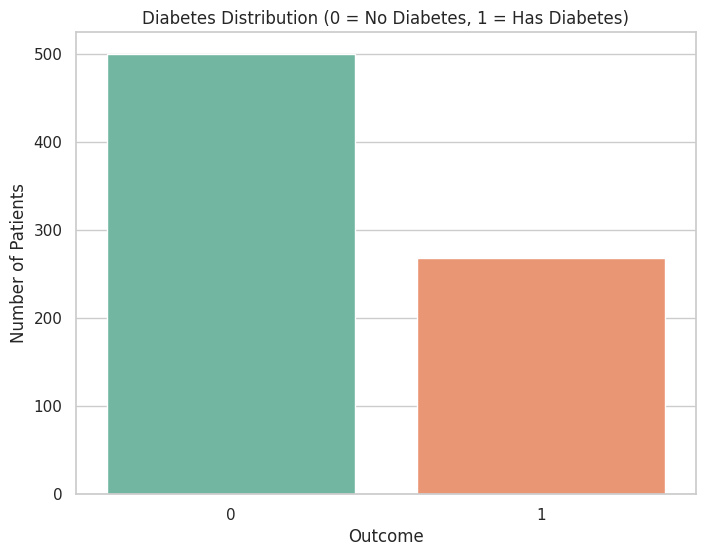

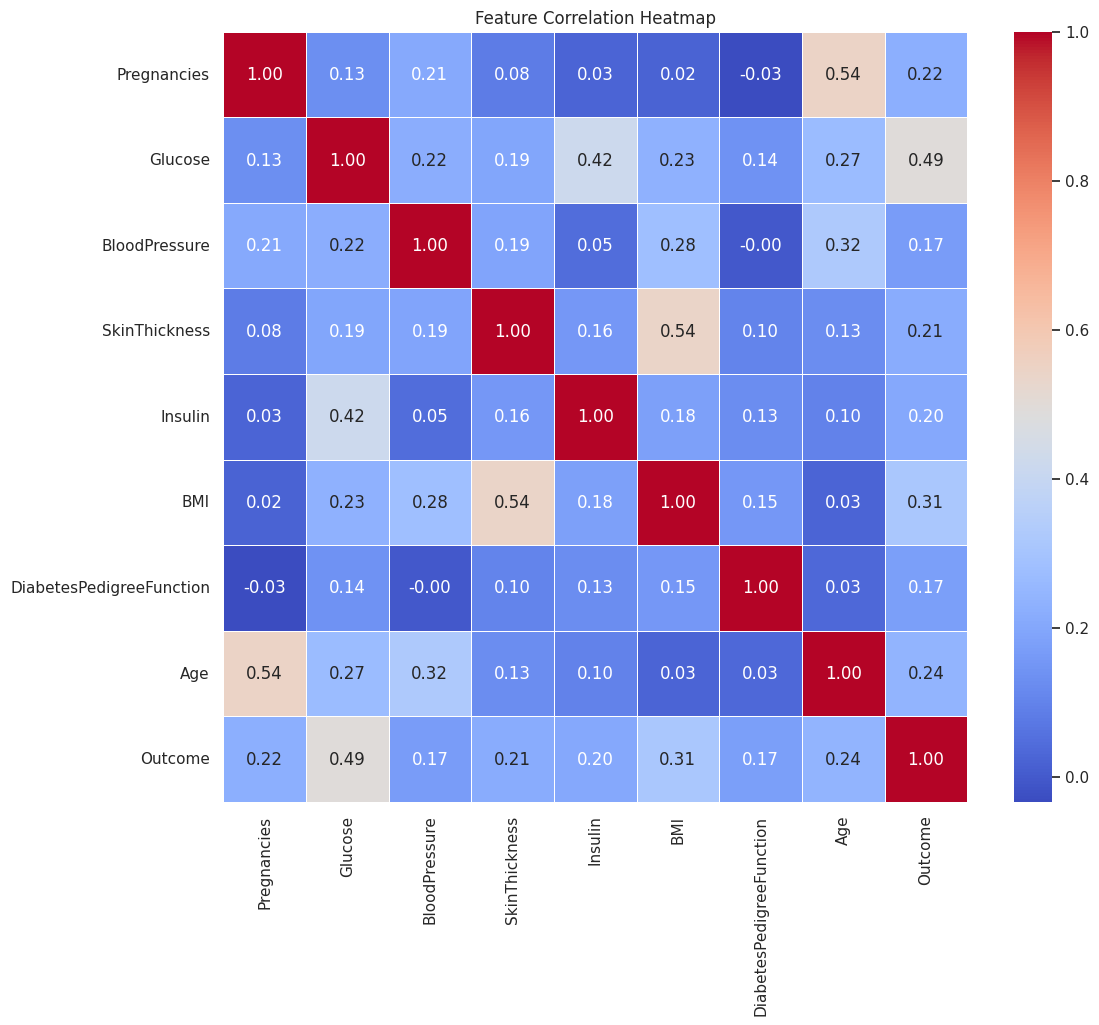

In [22]:
# Distribution of Diabetes Outcome
plt.figure(figsize=(8, 6))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title("Diabetes Distribution (0 = No Diabetes, 1 = Has Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


### DATA SLPITING FOR TESTING AND TRAINING

In [23]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data Split Summary:")
print("Training set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Data Split Summary:
Training set shape: (614, 8)
Testing set shape:  (154, 8)
Training samples: 614
Testing samples:  154


### FEATURE SCALLING



In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### TRAINING THE MODEL

In [26]:
model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

### PREDICTIONS

In [28]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

### EVALUATIONS

=== Model Performance Evaluation ===

Accuracy: 0.7532 (75.32%)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



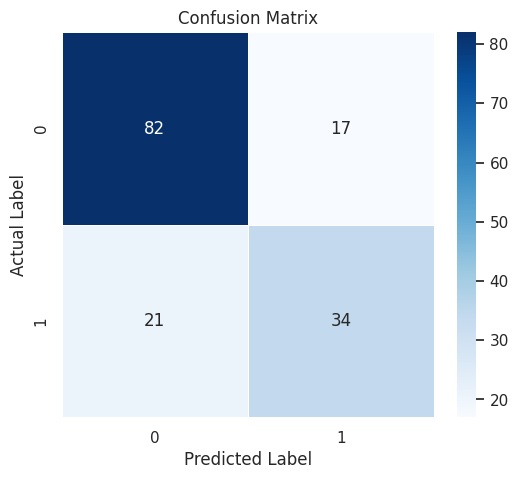

True Negatives : 82
False Positives: 17
False Negatives: 21
True Positives : 34


In [29]:
# Model Evaluation
print("=== Model Performance Evaluation ===\n")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(f"True Negatives : {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives : {cm[1][1]}")

###

###

### ROC CURVE AND AUC SCORE

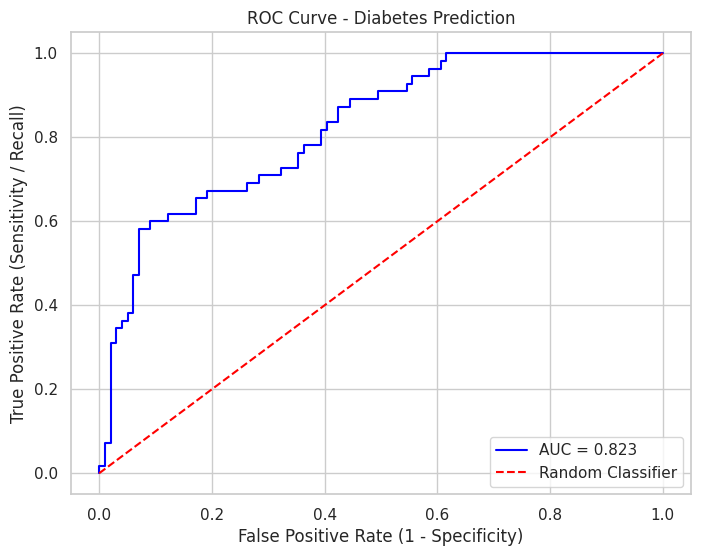

ROC AUC Score: 0.8228


In [ ]:
# ROC Curve and AUC Score
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]   # Probability of having diabetes

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - Diabetes Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

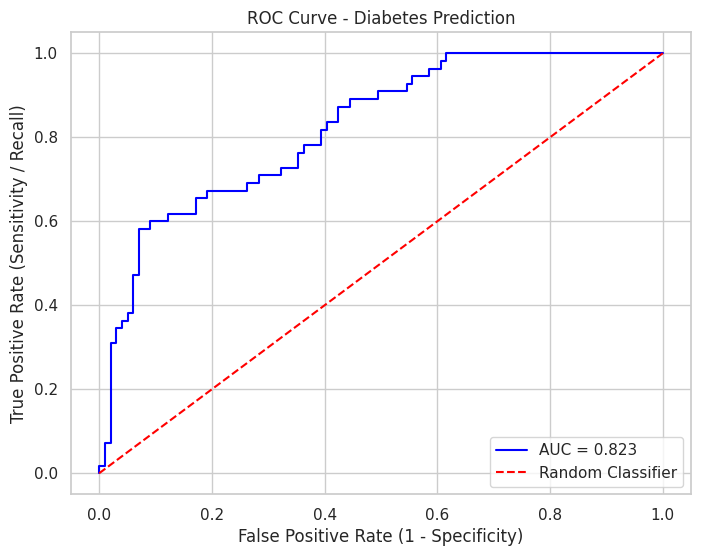

ROC AUC Score: 0.8228


In [32]:
# ROC Curve and AUC Score
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]   # Probability of having diabetes

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - Diabetes Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

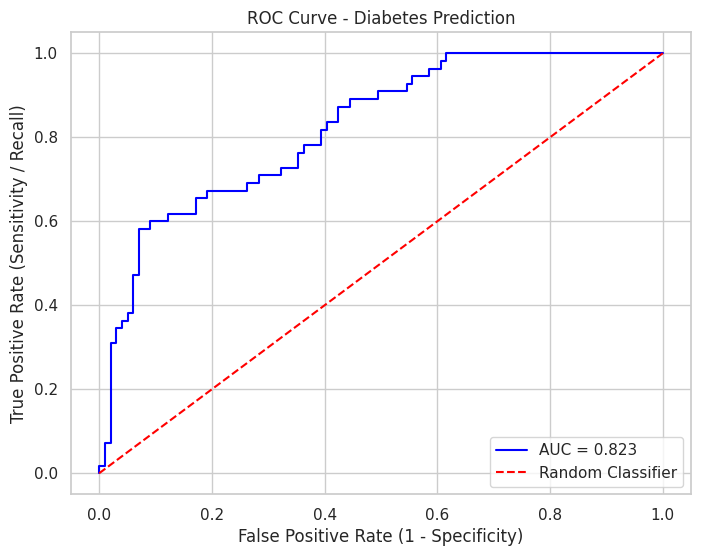

ROC AUC Score: 0.8228


In [33]:
# ROC Curve and AUC Score
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]   # Probability of having diabetes

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - Diabetes Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

=== Feature Importance (Logistic Regression Coefficients) ===

                    Feature  Coefficient
1                   Glucose       1.1027
5                       BMI       0.6888
7                       Age       0.3924
0               Pregnancies       0.2230
6  DiabetesPedigreeFunction       0.2036
3             SkinThickness       0.0688
4                   Insulin      -0.1383
2             BloodPressure      -0.1515


/tmp/ipykernel_2279/1192690223.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coefficient", y="Feature", data=coefficients, palette="coolwarm")


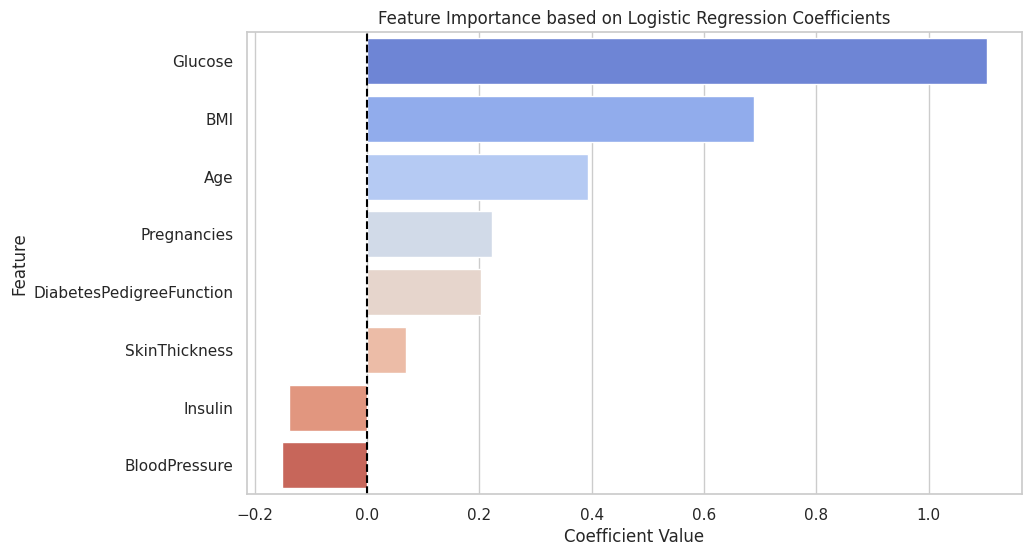

In [34]:
# Feature Importance using Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,       # Original feature names
    "Coefficient": model.coef_[0]
})

# Sort by importance
coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print("=== Feature Importance (Logistic Regression Coefficients) ===\n")
print(coefficients.round(4))   # Show 4 decimal places for neatness

# Plot the coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=coefficients, palette="coolwarm")
plt.title("Feature Importance based on Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

# **Diabetes Prediction Using Logistic Regression**

## **Introduction**

This project focuses on predicting whether a patient has diabetes using the Pima Indians Diabetes dataset. The task is a binary classification problem where the outcome variable takes the value **0 (non-diabetic)** or **1 (diabetic)**. Early prediction of diabetes is crucial in healthcare, making this model practically relevant and impactful.

---

## **Data Preprocessing**

Real-world data is rarely perfect, and this dataset is no exception. Several features such as *Glucose, Blood Pressure, Skin Thickness, Insulin,* and *BMI* contained zero values, which are not medically realistic. These values were treated as missing and replaced using the **median** of each respective feature to maintain data integrity.

Additionally, feature scaling was applied using **StandardScaler** to normalize the data. This ensures that all features contribute equally to the model and prevents bias toward variables with larger numerical ranges.

---

## **Exploratory Data Analysis (EDA)**

Exploratory analysis was conducted to understand the dataset better. A count plot revealed the distribution of diabetic and non-diabetic patients, giving insight into class balance.

A correlation heatmap was also generated to examine relationships between variables. The analysis showed that **Glucose levels**, **BMI**, and **Age** have strong relationships with the likelihood of diabetes, making them key predictive features.

---

## **Model Selection**

The **Logistic Regression** algorithm was chosen for this task because it is well-suited for binary classification problems. It models the probability of a given input belonging to a particular class and provides interpretable coefficients, allowing us to understand the influence of each feature on the prediction.

---

## **Model Training and Prediction**

The dataset was split into training and testing sets using an 80–20 ratio. The model was trained on the training data and then used to make predictions on unseen test data.

---

## **Model Evaluation**

The performance of the model was evaluated using multiple metrics:

* **Accuracy Score** – measures overall correctness
* **Confusion Matrix** – shows correct and incorrect predictions
* **Classification Report** – includes precision, recall, and F1-score
* **ROC Curve and AUC Score** – evaluates the model’s ability to distinguish between classes

The ROC curve demonstrated that the model has a good ability to separate diabetic and non-diabetic cases, with a satisfactory AUC score.

---

## **Key Insights**

* **Glucose level** emerged as the most influential predictor of diabetes
* **BMI and Age** also showed strong contributions to the model
* The model achieved reasonable accuracy, indicating it captures meaningful patterns in the data
* However, there is still room for improvement using more advanced techniques

---

## **Conclusion**

The Logistic Regression model successfully predicts whether a patient has diabetes with good accuracy. While the model performs well, its performance can be further enhanced through techniques such as hyperparameter tuning or the use of more complex models like ensemble methods.

This project demonstrates how machine learning can be applied to healthcare data to support early diagnosis and decision-making.

---

## **Final Notes**

* The implementation was carried out using Python in Jupyter Notebook / Google Colab
* Proper data preprocessing and evaluation were key to achieving reliable results
* All visualizations and metrics were used to support and validate the model’s performance

---
